# Testing FASTT-Alternating DiagonalGating

This notebook provides an interactive environment to test the feature selection capabilities of `FASTTAlternating` using the `diagonal` transform paired with a non-differentiable `AdaSTTXGBoost` selector. 

Because this notebook is renderable by our CCDS documentation generators (such as `mkdocs-jupyter`, `Sphinx`, or `Quarto`), we can include rich outputs and visualizations directly alongside our documentation.

In [ ]:
import os
import sys

# Ensure the project root is on the path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import mlflow

from s2t_fs.data.synthetic import generate_synthetic_data
from s2t_fs.models.fastt.fastt_alternating import FASTTAlternating
from s2t_fs.models.adastt_xgboost import AdaSTTXGBoost
from s2t_fs.utils.logger import custom_logger as logger


## 1. Synthetic Data Generation

We generate a synthetic dataset with exactly **5 informative** features and **25 noise** features. Our goal is to ensure the alternating gradient strategy learns to ignore the 25 noisy features while assigning high importance to the informative ones.

In [5]:
data_params = {
    "n_samples": 4000,
    "n_informative": 5,
    "n_noise": 25,
    "n_experts": 3,
    "test_size": 0.2,
    "seed": 0
}

X_train, Y_train, X_test, Y_test, stats = generate_synthetic_data(data_params)
print(f"Data generated: {stats['num_total_rows']} rows, {stats['num_features']} total features")

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3908


Data generated: 4000 rows, 30 total features


## 2. Model Training

We instantiate an `AdaSTTXGBoost` classifier and pass it to the `FASTTAlternating` algorithm. Over `num_iterations=5` alternating rounds, the algorithm will iteratively fit the XGBoost selector on transformed features, construct a linear surrogate objective mapping inputs to the leaf probability output space, and gradient descent the `diagonal` transformation weights.

In [3]:
base_selector = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, early_stopping_rounds=10)

model = FASTTAlternating(
    base_selector=base_selector,
    transform_type="diagonal",
    transform_kwargs={"lambda1": 0.05, "lambda2": 0.01},
    num_iterations=20,
    transform_lr=1e-2,
    transform_steps=200,
    random_state=42
)

model.fit(X_train, Y_train)

,base_selector,AdaSTTXGBoost...estimators=50)
,transform_type,'diagonal'
,transform_kwargs,"{'lambda1': 0.05, 'lambda2': 0.01}"
,num_iterations,20
,transform_lr,0.01
,transform_steps,200
,random_state,42
,n_estimators,50
,learning_rate,0.1
,max_depth,4
,subsample,0.8


## 3. Visualization of Alternating Gating Weights

Because the alternating algorithm uses a global wrapper transform (rather than nested routing boosts), `model.get_gating_weights()` extracts a single 1D vector detailing the holistic dimension importance mapping.

We should observe distinct magnitude spikes for the first 5 features (informative) and a flat baseline near zero for the remaining 25 features.

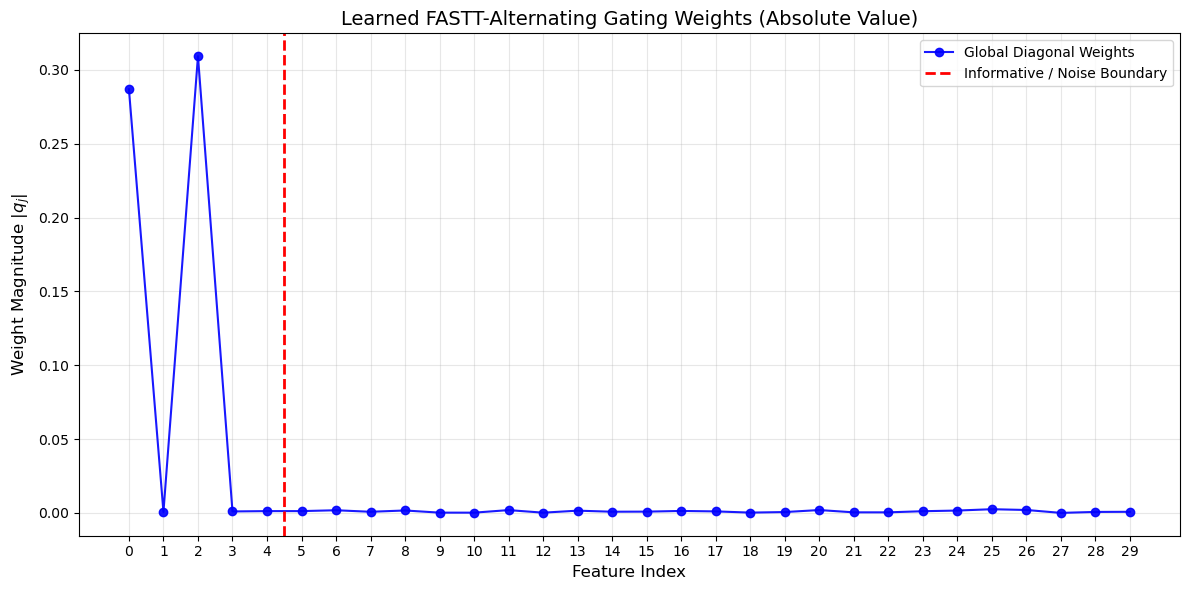

In [4]:
gating_weights = model.get_gating_weights()

plt.figure(figsize=(12, 6))
plt.plot(np.abs(gating_weights), marker='o', alpha=0.9, color='blue', label='Global Diagonal Weights')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title('Learned FASTT-Alternating Gating Weights (Absolute Value)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
gating_weights

array([-2.8689542e-01,  6.5439864e-04,  3.0926245e-01,  1.0075297e-03,
        1.2319748e-03,  1.2336405e-03, -1.8135677e-03, -7.7611255e-04,
       -1.6579663e-03,  1.9335942e-04,  1.8215622e-04,  1.9123898e-03,
       -1.7007807e-04,  1.5352488e-03, -8.1472879e-04,  8.7956508e-04,
        1.3427517e-03,  1.0358598e-03, -2.1906829e-04, -5.8734894e-04,
       -1.9493834e-03, -3.8991496e-04, -3.9337610e-04,  1.1547237e-03,
       -1.6089007e-03,  2.5152778e-03,  1.9894205e-03, -2.6222784e-05,
        6.6947821e-04, -7.6257624e-04], dtype=float32)

## 4. Robustness Analysis (20 Iterations)

To analyze the performance and robustness of the `FASTT-Alternating` algorithm, we repeat the experiment 20 times with different random seeds for data generation and model initialization. We then plot the average gating weights across all iterations to verify that the algorithm consistently identifies the informative features.

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3908


Running 20 iterations of the FASTT-Alternating algorithm...


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4348


Iteration 1/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4092


Iteration 2/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3737


Iteration 3/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3580


Iteration 4/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3784


Iteration 5/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3964


Iteration 6/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4061


Iteration 7/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3871


Iteration 8/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3697


Iteration 9/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4290


Iteration 10/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3696


Iteration 11/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3725


Iteration 12/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4137


Iteration 13/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3647


Iteration 14/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3864


Iteration 15/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3662


Iteration 16/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3732


Iteration 17/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3725


Iteration 18/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3730


Iteration 19/20 completed.


Iteration 20/20 completed.


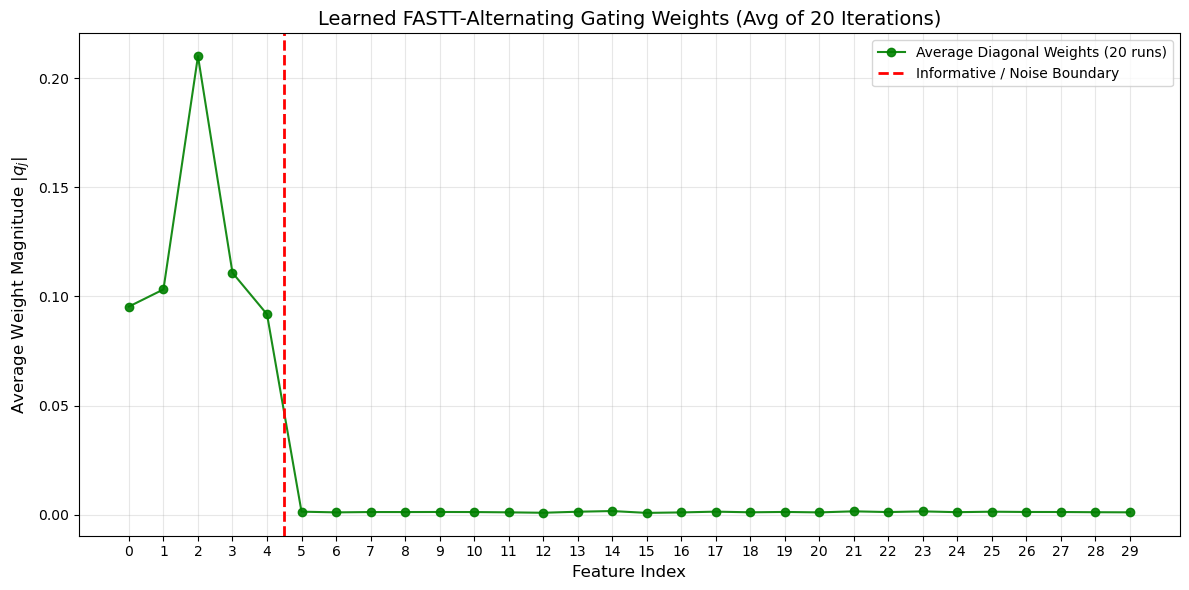

In [6]:
num_experiments = 20
all_gating_weights = []

print(f"Running {num_experiments} iterations of the FASTT-Alternating algorithm...")

for i in range(num_experiments):
    # 1. Generate new synthetic data with a different seed
    current_data_params = data_params.copy()
    current_data_params["seed"] = i
    
    # Suppress output during the loop for cleaner output
    import contextlib
    import io
    import sys
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        X_train_i, Y_train_i, X_test_i, Y_test_i, _ = generate_synthetic_data(current_data_params)
        
        base_selector_i = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, early_stopping_rounds=10)
        
        model_i = FASTTAlternating(
            base_selector=base_selector_i,
            transform_type="diagonal",
            transform_kwargs={"lambda1": 0.05, "lambda2": 0.01},
            num_iterations=20,
            transform_lr=1e-2,
            transform_steps=200,
            random_state=i # Vary model seed as well
        )
        model_i.fit(X_train_i, Y_train_i)
        
    weights_i = model_i.get_gating_weights()
    all_gating_weights.append(np.abs(weights_i))
    print(f"Iteration {i+1}/{num_experiments} completed.")

# Calculate average weights
avg_gating_weights = np.mean(all_gating_weights, axis=0)

# Plotting the average results
plt.figure(figsize=(12, 6))
plt.plot(avg_gating_weights, marker='o', alpha=0.9, color='green', label=f'Average Diagonal Weights ({num_experiments} runs)')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title(f'Learned FASTT-Alternating Gating Weights (Avg of {num_experiments} Iterations)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Average Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Config-Driven Hyperparameter Tuning (Optuna)

Following strict architectural guidelines, we define the entire model and hyperparameter space natively via a configuration dictionary. Using the generic `prepare_model_from_config` registry, our custom `FASTTAlternating` algorithm is dynamically instantiated along with its nested `base_selector` dependencies.

Because our architecture enforces the **Scikit-Learn Estimator API**, we can treat `OptunaSearchCV` as a first-class estimator and simply `.fit()` it. We also cleanly log all artifacts using the centralized `log_experiment_results` MLflow utility.

In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from s2t_fs.models.registry import prepare_model_from_config
from optuna.integration import OptunaSearchCV
from sklearn.model_selection import ShuffleSplit
import mlflow
from s2t_fs.utils.mlflow_utils import log_experiment_results
import os
import sys

# Ensure the project root is on the path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import mlflow

from s2t_fs.data.synthetic import generate_synthetic_data
from s2t_fs.models.fastt.fastt_alternating import FASTTAlternating
from s2t_fs.models.adastt_xgboost import AdaSTTXGBoost
from s2t_fs.utils.logger import custom_logger as logger

data_params = 

X_train, Y_train, X_test, Y_test, stats = generate_synthetic_data(data_params)
print(f"Data generated: {stats['num_total_rows']} rows, {stats['num_features']} total features")


# 1. Define the experiment as a strict configuration dictionary
cfg = {
    "mlflow_cfg": {
        "tracking_uri": "sqlite:///mlruns_nested_try.db",
        "experiment_name": "Nested Child Association"
    },
    "data_cfg": {
        "n_samples": 4000,
        "n_informative": 5,
        "n_noise": 25,
        "n_experts": 3,
        "test_size": 0.2,
        "seed": 0
    },
    "search_cfg": {
        "seed": 42,
        "num_samples": 2,
        "num_folds": 1,
        "test_size": 0.1,
        "refit": true
    },
    "model_cfg": {
        "model_name": "FASTTAlternating-Tuned",
        "class_path": "s2t_fs.models.fastt.fastt_alternating.FASTTAlternating",
        "init_args": {
            "transform_type": "diagonal",
            "transform_steps": 100,
            "random_state": 42,
            "base_selector": {
                "class_path": "s2t_fs.models.adastt_xgboost.AdaSTTXGBoost",
                "init_args": {
                    "n_estimators": 50,
                    "learning_rate": 0.1
                }
            }
        },
        "hyperparameters": {
            "num_iterations": [5, 10],
            "transform_lr": [1e-3, 1e-2],
            "base_selector__max_depth": [3, 4]
        }
    }
}



# 2. Parse the config securely using the registry
model_name, model_instance, optuna_space = prepare_model_from_config(cfg["model_cfg"])

# 3. Instantiate the Scikit-Learn OptunaSearchCV Estimator
search = OptunaSearchCV(
    estimator=model_instance,
    param_distributions=optuna_space,
    cv=ShuffleSplit(n_splits=2, test_size=0.2, random_state=42),
    n_trials=4,
    random_state=42,
    refit=True
)

# 4. Fit natively under an MLflow tracking run
mlflow.set_experiment("FASTT_Notebook_Tuning")

with mlflow.start_run(run_name="FASTT_Optuna_Trial") as run:
    print(f"Starting Optuna search for {model_name}...")
    
    # Fit the estimator on the preloaded data
    search.fit(X_train, Y_train)
    
    # Evaluate the best estimator
    preds = search.predict(X_test)
    wer_best = float(Y_test[np.arange(len(Y_test)), preds].mean())
    print(f"Best Test WER: {wer_best:.4f}")
    
    # Log results to MLflow using the centralized custom utility
    log_experiment_results(search, wer_best, stats)
    
    # Extract the gating weights from the best fitted model to prove feature selection
    best_model = search.best_estimator_
    gating_weights_tuned = best_model.get_gating_weights()

Starting Optuna search for FASTTAlternating-Tuned...


    Trial 0 finished with value: -0.3978550583124161 and parameters: {'num_iterations': 10, 'transform_lr': 0.01, 'base_selector__max_depth': 3}. Best is trial 0 with value: -0.3978550583124161.
    Trial 1 finished with value: -0.3977587819099426 and parameters: {'num_iterations': 5, 'transform_lr': 0.01, 'base_selector__max_depth': 4}. Best is trial 1 with value: -0.3977587819099426.
    Trial 2 finished with value: -0.3977587819099426 and parameters: {'num_iterations': 5, 'transform_lr': 0.01, 'base_selector__max_depth': 4}. Best is trial 1 with value: -0.3977587819099426.
    Trial 3 finished with value: -0.3978550583124161 and parameters: {'num_iterations': 10, 'transform_lr': 0.01, 'base_selector__max_depth': 3}. Best is trial 1 with value: -0.3977587819099426.


Best Test WER: 0.3978


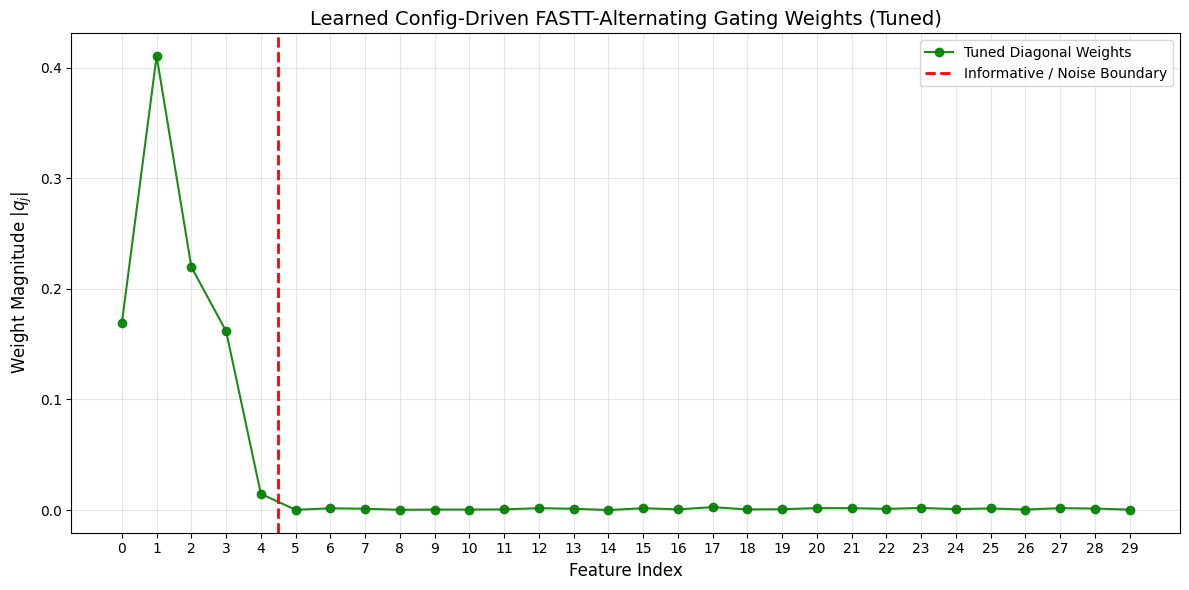

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(np.abs(gating_weights_tuned), marker='o', alpha=0.9, color='green', label='Tuned Diagonal Weights')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title('Learned Config-Driven FASTT-Alternating Gating Weights (Tuned)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Trying to write better

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3908
Data generated: 4000 rows, 30 total features
Starting Optuna search for FASTTAlternating-Tuned...
    Trial 0 finished with value: -0.3961072564125061 and parameters: {'num_iterations': 10, 'transform_lr': 0.01, 'base_selector__max_depth': 3}. Best is trial 0 with value: -0.3961072564125061.
    Trial 1 finished with value: -0.39602890610694885 and parameters: {'num_iterations': 5, 'transform_lr': 0.01, 'base_selector__max_depth': 4}. Best is trial 1 with value: -0.39602890610694885.
Best Test WER: 0.3978
Saved gating weights plot to MLflow artifacts.


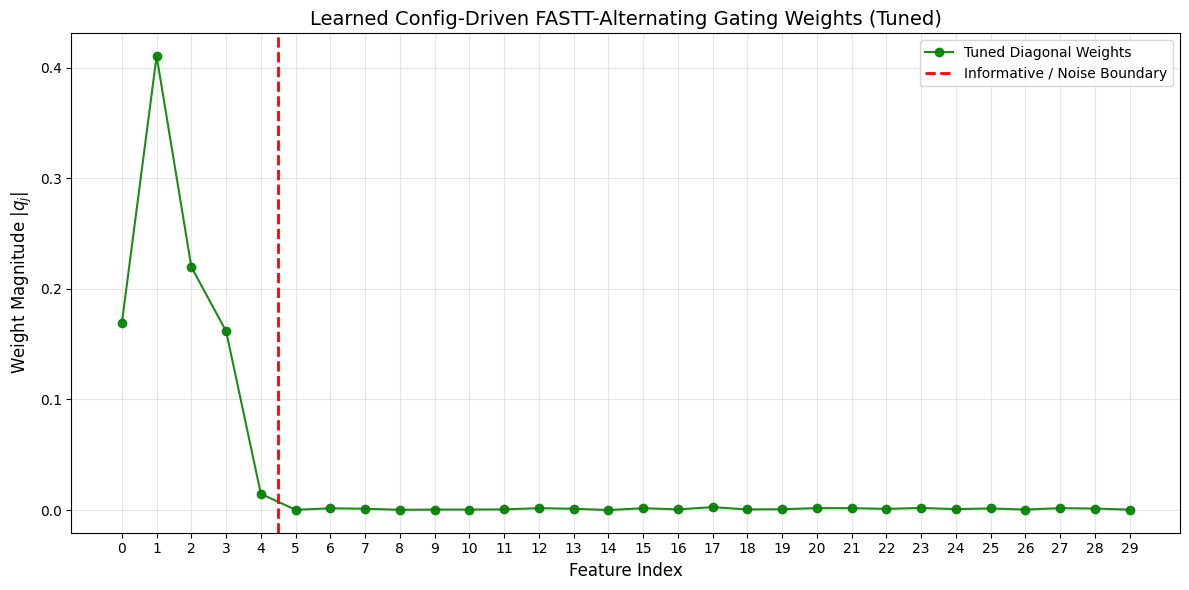

In [11]:
import os
import sys

# Ensure the project root is on the path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import mlflow
from optuna.integration import OptunaSearchCV
from sklearn.model_selection import ShuffleSplit

from s2t_fs.models.registry import prepare_model_from_config
from s2t_fs.utils.mlflow_utils import log_experiment_metadata, log_experiment_results
from s2t_fs.data.synthetic import generate_synthetic_data
from s2t_fs.models.fastt.fastt_alternating import FASTTAlternating
from s2t_fs.models.adastt_xgboost import AdaSTTXGBoost
from s2t_fs.utils.logger import custom_logger as logger

# 1. Define the experiment as a strict configuration dictionary
cfg = {
    "mlflow_cfg": {
        "tracking_uri": "sqlite:///../mlruns_nested_try.db",
        "experiment_name": "Check",
        "run_name": "FASTT_Optuna_Trial"
    },
    "data_cfg": {
        "n_samples": 4000,
        "n_informative": 5,
        "n_noise": 25,
        "n_experts": 3,
        "test_size": 0.2,
        "seed": 0
    },
    "search_cfg": {
        "seed": 42,
        "num_samples": 2,
        "num_folds": 1,
        "test_size": 0.1,
        "refit": True
    },
    "model_cfg": {
        "model_name": "FASTTAlternating-Tuned",
        "class_path": "s2t_fs.models.fastt.fastt_alternating.FASTTAlternating",
        "init_args": {
            "transform_type": "diagonal",
            "transform_steps": 100,
            "random_state": 42,
            "base_selector": {
                "class_path": "s2t_fs.models.adastt_xgboost.AdaSTTXGBoost",
                "init_args": {
                    "n_estimators": 50,
                    "learning_rate": 0.1
                }
            }
        },
        "hyperparameters": {
            "num_iterations": [5, 10],
            "transform_lr": [1e-3, 1e-2],
            "base_selector__max_depth": [3, 4]
        }
    }
}

# 2. Generate Data using the config
X_train, Y_train, X_test, Y_test, stats = generate_synthetic_data(cfg["data_cfg"])
logger.info(f"Data generated: {stats['num_total_rows']} rows, {stats['num_features']} total features")

# 3. Parse the config securely using the registry
model_name, model_instance, optuna_space = prepare_model_from_config(cfg["model_cfg"])

# 4. Instantiate the Scikit-Learn OptunaSearchCV Estimator
search = OptunaSearchCV(
    estimator=model_instance,
    param_distributions=optuna_space,
    cv=ShuffleSplit(
        n_splits=cfg["search_cfg"]["num_folds"], 
        test_size=cfg["search_cfg"]["test_size"], 
        random_state=cfg["search_cfg"]["seed"]
    ),
    n_trials=cfg["search_cfg"]["num_samples"],
    random_state=cfg["search_cfg"]["seed"],
    refit=cfg["search_cfg"]["refit"]
)

# 5. MLflow Tracking Setup
mlflow.set_tracking_uri(cfg["mlflow_cfg"]["tracking_uri"])
mlflow.set_experiment(cfg["mlflow_cfg"]["experiment_name"])

with mlflow.start_run(run_name=cfg["mlflow_cfg"]["FASTT_Optuna_Trial"]) as run:
    logger.info(f"Starting Optuna search for {model_name}...")
    
    # Fit the estimator on the preloaded data
    search.fit(X_train, Y_train)
    
    # Evaluate the best estimator
    preds = search.predict(X_test)
    wer_best = float(Y_test[np.arange(len(Y_test)), preds].mean())
    logger.info(f"Best Test WER: {wer_best:.4f}")
    
    # Log config and results to MLflow using the centralized custom utility
    log_experiment_metadata(cfg)
    log_experiment_results(search, wer_best, stats)
    
    # Extract the gating weights from the best fitted model
    best_model = search.best_estimator_
    gating_weights_tuned = best_model.get_gating_weights()
    
    # 6. Plotting and Artifact Logging
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(np.abs(gating_weights_tuned), marker='o', alpha=0.9, color='green', label='Tuned Diagonal Weights')
    
    ax.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
    ax.set_title('Learned Config-Driven FASTT-Alternating Gating Weights (Tuned)', fontsize=14)
    ax.set_xlabel('Feature Index', fontsize=12)
    ax.set_ylabel('Weight Magnitude $|q_j|$', fontsize=12)
    ax.set_xticks(range(30))
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    # Log the figure natively to MLflow as an artifact
    mlflow.log_figure(fig, "gating_weights_tuned.png")
    logger.info("Saved gating weights plot to MLflow artifacts.")
    
    # Display locally
    plt.show()